### Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Data Loading

In [2]:
xls = pd.ExcelFile('Georgian College AI Modelling Data Dictionary (2023.01.25 IK).xlsx')
data_dict = pd.read_excel(xls, 'Data Dictionary')
df = pd.read_excel(xls, 'ADRS Data')

In [3]:
df.head()

,CallNum,CallHour,PickupTown,Utm,OverallProblem,DestinationLocationName,DestinationCity,NotifyUtm,NotifyLowerTierDescription,DispatchedPriority,...,Day,Week,Quarter,Dispatch,Chute,Resp,ONSCNE,INHOSP,TOTALT0T7,TOTALT0T13
0,15022670,6,BARRIE,6054917.0,*Primary Assessment,NaN,NaN,6024919,Springwater,4,...,9,46,4,1900-01-01 00:00:33,1900-01-01 00:01:38,NaT,NaT,NaN,NaT,1900-01-01 00:11:56
1,15022670,6,BARRIE,6054917.0,*Primary Assessment,1825 Royal Victoria RVH HO,BARRIE,6034914,Barrie,4,...,9,46,4,1900-01-01 00:03:08,1900-01-01 00:00:28,1900-01-01 00:06:59,1900-01-01 00:07:30,1900-01-01 01:20:48,1900-01-01 01:43:54,NaN
2,15022685,7,MIDLAND,5874954.0,11 Chest Pain/Heart Problem,1844 Georgian Bay General Site 1 HO,MIDLAND,5894953,Midland,4,...,9,46,4,1900-01-01 00:01:59,1900-01-01 00:00:02,1900-01-01 00:04:33,1900-01-01 00:19:01,1900-01-01 00:32:51,1900-01-01 01:02:15,NaN
3,15022688,7,TAY,5914945.0,24A MVC-AutomobileEnclSeat_pa,1844 Georgian Bay General Site 1 HO,MIDLAND,5894953,Midland,4,...,9,46,4,1900-01-01 00:00:20,1900-01-01 00:00:53,1900-01-01 00:09:13,1900-01-01 00:19:27,1900-01-01 00:56:56,1900-01-01 01:38:21,NaN
4,15022688,7,TAY,5914945.0,24A MVC-AutomobileEnclSeat_pa,1844 Georgian Bay General Site 1 HO,MIDLAND,6074951,Severn,4,...,9,46,4,1900-01-01 00:03:07,1900-01-01 00:01:08,1900-01-01 00:16:17,1900-01-01 00:20:02,1900-01-01 00:34:04,1900-01-01 01:25:17,NaN


In [4]:
df2 = df.copy()

In [5]:
df2.head()

,CallNum,CallHour,PickupTown,Utm,OverallProblem,DestinationLocationName,DestinationCity,NotifyUtm,NotifyLowerTierDescription,DispatchedPriority,...,Day,Week,Quarter,Dispatch,Chute,Resp,ONSCNE,INHOSP,TOTALT0T7,TOTALT0T13
0,15022670,6,BARRIE,6054917.0,*Primary Assessment,NaN,NaN,6024919,Springwater,4,...,9,46,4,1900-01-01 00:00:33,1900-01-01 00:01:38,NaT,NaT,NaN,NaT,1900-01-01 00:11:56
1,15022670,6,BARRIE,6054917.0,*Primary Assessment,1825 Royal Victoria RVH HO,BARRIE,6034914,Barrie,4,...,9,46,4,1900-01-01 00:03:08,1900-01-01 00:00:28,1900-01-01 00:06:59,1900-01-01 00:07:30,1900-01-01 01:20:48,1900-01-01 01:43:54,NaN
2,15022685,7,MIDLAND,5874954.0,11 Chest Pain/Heart Problem,1844 Georgian Bay General Site 1 HO,MIDLAND,5894953,Midland,4,...,9,46,4,1900-01-01 00:01:59,1900-01-01 00:00:02,1900-01-01 00:04:33,1900-01-01 00:19:01,1900-01-01 00:32:51,1900-01-01 01:02:15,NaN
3,15022688,7,TAY,5914945.0,24A MVC-AutomobileEnclSeat_pa,1844 Georgian Bay General Site 1 HO,MIDLAND,5894953,Midland,4,...,9,46,4,1900-01-01 00:00:20,1900-01-01 00:00:53,1900-01-01 00:09:13,1900-01-01 00:19:27,1900-01-01 00:56:56,1900-01-01 01:38:21,NaN
4,15022688,7,TAY,5914945.0,24A MVC-AutomobileEnclSeat_pa,1844 Georgian Bay General Site 1 HO,MIDLAND,6074951,Severn,4,...,9,46,4,1900-01-01 00:03:07,1900-01-01 00:01:08,1900-01-01 00:16:17,1900-01-01 00:20:02,1900-01-01 00:34:04,1900-01-01 01:25:17,NaN


In [6]:
df2.isnull().sum()

CallNum                            0
CallHour                           0
PickupTown                        10
Utm                                1
OverallProblem                     2
DestinationLocationName       214713
DestinationCity               215429
NotifyUtm                          0
NotifyLowerTierDescription      3498
DispatchedPriority                 0
OverallPriorityCode               31
ReturnPriorityAtT5            216660
ReturnPriorityAtT6            217559
CTAS                           14435
SCA_PT1                       554424
T0_TimeZero                       35
T1_CallReceived                    0
T2_Notified                        0
T3_Enroute                         0
T4_ArrivedScene                67629
T5_DepartScene                216126
T6_ArriveDestination          217072
PTOC                          220423
T7_ClearDestination           217478
T11TimeCallTakingComplete        783
T13_UnitCancelled             363519
RespondingFromStationName          0
D

In [7]:
df2 = df2[['CallHour', 'PickupTown', 'Utm', 'NotifyUtm', 'OverallProblem', 'DispatchedPriority', 'OverallPriorityCode', 'Year' , 'Month', 'Day', 'Week', 'Quarter', 'T4_ArrivedScene', 'T2_Notified', 'NotifyLowerTierDescription']]

In [8]:
df2.head()

,CallHour,PickupTown,Utm,NotifyUtm,OverallProblem,DispatchedPriority,OverallPriorityCode,Year,Month,Day,Week,Quarter,T4_ArrivedScene,T2_Notified,NotifyLowerTierDescription
0,6,BARRIE,6054917.0,6024919,*Primary Assessment,4,4.0,2015,11,9,46,4,NaT,2015-11-09 06:12:37,Springwater
1,6,BARRIE,6054917.0,6034914,*Primary Assessment,4,4.0,2015,11,9,46,4,2015-11-09 06:22:11,2015-11-09 06:15:12,Barrie
2,7,MIDLAND,5874954.0,5894953,11 Chest Pain/Heart Problem,4,4.0,2015,11,9,46,4,2015-11-09 07:41:37,2015-11-09 07:37:04,Midland
3,7,TAY,5914945.0,5894953,24A MVC-AutomobileEnclSeat_pa,4,4.0,2015,11,9,46,4,2015-11-09 08:07:11,2015-11-09 07:57:58,Midland
4,7,TAY,5914945.0,6074951,24A MVC-AutomobileEnclSeat_pa,4,4.0,2015,11,9,46,4,2015-11-09 08:17:02,2015-11-09 08:00:45,Severn


In [9]:
#df2['Resp'] = (df['T4_ArrivedScene'] - df['T2_Notified'])
#df2['Resp'] = df['Resp']/np.timedelta64(1, 'm')

In [10]:
df2.isnull().sum()

CallHour                          0
PickupTown                       10
Utm                               1
NotifyUtm                         0
OverallProblem                    2
DispatchedPriority                0
OverallPriorityCode              31
Year                              0
Month                             0
Day                               0
Week                              0
Quarter                           0
T4_ArrivedScene               67629
T2_Notified                       0
NotifyLowerTierDescription     3498
dtype: int64

In [11]:
df2.dtypes

CallHour                               int64
PickupTown                            object
Utm                                  float64
NotifyUtm                              int64
OverallProblem                        object
DispatchedPriority                     int64
OverallPriorityCode                  float64
Year                                   int64
Month                                  int64
Day                                    int64
Week                                   int64
Quarter                                int64
T4_ArrivedScene               datetime64[ns]
T2_Notified                   datetime64[ns]
NotifyLowerTierDescription            object
dtype: object

In [12]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

categorical_cols = ["PickupTown", "OverallProblem"]
encoder = LabelEncoder()
for c in categorical_cols:
    df2[c] = encoder.fit_transform(df2[c])

In [13]:
df2.head()

,CallHour,PickupTown,Utm,NotifyUtm,OverallProblem,DispatchedPriority,OverallPriorityCode,Year,Month,Day,Week,Quarter,T4_ArrivedScene,T2_Notified,NotifyLowerTierDescription
0,6,3,6054917.0,6024919,1,4,4.0,2015,11,9,46,4,NaT,2015-11-09 06:12:37,Springwater
1,6,3,6054917.0,6034914,1,4,4.0,2015,11,9,46,4,2015-11-09 06:22:11,2015-11-09 06:15:12,Barrie
2,7,39,5874954.0,5894953,36,4,4.0,2015,11,9,46,4,2015-11-09 07:41:37,2015-11-09 07:37:04,Midland
3,7,66,5914945.0,5894953,85,4,4.0,2015,11,9,46,4,2015-11-09 08:07:11,2015-11-09 07:57:58,Midland
4,7,66,5914945.0,6074951,85,4,4.0,2015,11,9,46,4,2015-11-09 08:17:02,2015-11-09 08:00:45,Severn


In [14]:
df2.dtypes

CallHour                               int64
PickupTown                             int32
Utm                                  float64
NotifyUtm                              int64
OverallProblem                         int32
DispatchedPriority                     int64
OverallPriorityCode                  float64
Year                                   int64
Month                                  int64
Day                                    int64
Week                                   int64
Quarter                                int64
T4_ArrivedScene               datetime64[ns]
T2_Notified                   datetime64[ns]
NotifyLowerTierDescription            object
dtype: object

In [15]:
df2.drop(['T4_ArrivedScene', 'T2_Notified'], inplace=True, axis=1)

In [16]:
df2.head()

,CallHour,PickupTown,Utm,NotifyUtm,OverallProblem,DispatchedPriority,OverallPriorityCode,Year,Month,Day,Week,Quarter,NotifyLowerTierDescription
0,6,3,6054917.0,6024919,1,4,4.0,2015,11,9,46,4,Springwater
1,6,3,6054917.0,6034914,1,4,4.0,2015,11,9,46,4,Barrie
2,7,39,5874954.0,5894953,36,4,4.0,2015,11,9,46,4,Midland
3,7,66,5914945.0,5894953,85,4,4.0,2015,11,9,46,4,Midland
4,7,66,5914945.0,6074951,85,4,4.0,2015,11,9,46,4,Severn


In [18]:
#minutes = duration.total_seconds() // 60
#df2['Resp'] = [x.total_seconds()//60 for x in df2['Resp']]

In [19]:
df2.dtypes

CallHour                        int64
PickupTown                      int32
Utm                           float64
NotifyUtm                       int64
OverallProblem                  int32
DispatchedPriority              int64
OverallPriorityCode           float64
Year                            int64
Month                           int64
Day                             int64
Week                            int64
Quarter                         int64
NotifyLowerTierDescription     object
dtype: object

In [20]:
df2.head()

,CallHour,PickupTown,Utm,NotifyUtm,OverallProblem,DispatchedPriority,OverallPriorityCode,Year,Month,Day,Week,Quarter,NotifyLowerTierDescription
0,6,3,6054917.0,6024919,1,4,4.0,2015,11,9,46,4,Springwater
1,6,3,6054917.0,6034914,1,4,4.0,2015,11,9,46,4,Barrie
2,7,39,5874954.0,5894953,36,4,4.0,2015,11,9,46,4,Midland
3,7,66,5914945.0,5894953,85,4,4.0,2015,11,9,46,4,Midland
4,7,66,5914945.0,6074951,85,4,4.0,2015,11,9,46,4,Severn


In [21]:
df2.isnull().sum()

CallHour                         0
PickupTown                       0
Utm                              1
NotifyUtm                        0
OverallProblem                   0
DispatchedPriority               0
OverallPriorityCode             31
Year                             0
Month                            0
Day                              0
Week                             0
Quarter                          0
NotifyLowerTierDescription    3498
dtype: int64

In [22]:
df2.dropna(inplace=True)

In [23]:
df2.isnull().sum()

CallHour                      0
PickupTown                    0
Utm                           0
NotifyUtm                     0
OverallProblem                0
DispatchedPriority            0
OverallPriorityCode           0
Year                          0
Month                         0
Day                           0
Week                          0
Quarter                       0
NotifyLowerTierDescription    0
dtype: int64

In [24]:
df2.shape

(552576, 13)

In [25]:
df2.head()

,CallHour,PickupTown,Utm,NotifyUtm,OverallProblem,DispatchedPriority,OverallPriorityCode,Year,Month,Day,Week,Quarter,NotifyLowerTierDescription
0,6,3,6054917.0,6024919,1,4,4.0,2015,11,9,46,4,Springwater
1,6,3,6054917.0,6034914,1,4,4.0,2015,11,9,46,4,Barrie
2,7,39,5874954.0,5894953,36,4,4.0,2015,11,9,46,4,Midland
3,7,66,5914945.0,5894953,85,4,4.0,2015,11,9,46,4,Midland
4,7,66,5914945.0,6074951,85,4,4.0,2015,11,9,46,4,Severn


In [26]:
df2['Utm'] = df2['Utm'].astype(int)

In [27]:
df2.head(2)

,CallHour,PickupTown,Utm,NotifyUtm,OverallProblem,DispatchedPriority,OverallPriorityCode,Year,Month,Day,Week,Quarter,NotifyLowerTierDescription
0,6,3,6054917,6024919,1,4,4.0,2015,11,9,46,4,Springwater
1,6,3,6054917,6034914,1,4,4.0,2015,11,9,46,4,Barrie


In [28]:
df3 = df2.copy()

In [29]:
df3['UTM Range'] = pd.cut(df3['Utm'], bins=[5634926, 5634927, 5864954, 5994912, 6034914, 6064918], labels=['UTM', 'UTM 1-2', 'UTM 1-3', 'UTM 1-4', 'UTM 1-5'])

In [30]:
df3.head()

,CallHour,PickupTown,Utm,NotifyUtm,OverallProblem,DispatchedPriority,OverallPriorityCode,Year,Month,Day,Week,Quarter,NotifyLowerTierDescription,UTM Range
0,6,3,6054917,6024919,1,4,4.0,2015,11,9,46,4,Springwater,UTM 1-5
1,6,3,6054917,6034914,1,4,4.0,2015,11,9,46,4,Barrie,UTM 1-5
2,7,39,5874954,5894953,36,4,4.0,2015,11,9,46,4,Midland,UTM 1-3
3,7,66,5914945,5894953,85,4,4.0,2015,11,9,46,4,Midland,UTM 1-3
4,7,66,5914945,6074951,85,4,4.0,2015,11,9,46,4,Severn,UTM 1-3


In [31]:
df3['UTM Range'].nunique()

5

<AxesSubplot:xlabel='UTM Range', ylabel='count'>

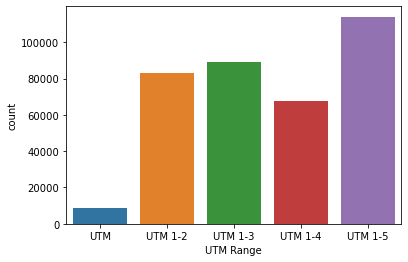

In [32]:
import seaborn as sns

sns.countplot(data=df3, x='UTM Range')

In [33]:
available_resources = pd.read_excel('Available_Resources.xlsx')

In [34]:
available_resources.head()

,Paramedic Station / Hour,Div,0,1,2,3,4,5,6,7,...,14,15,16,17,18,19,20,21,22,23
0,Alliston,NW,2,2,2,2,2,2,2,2,...,3,3,3,3,3,3,3,2,2,2
1,Angus,NW,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2,Barrie (Tiffin),S,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
3,Barrie (Stroud),S,2,2,2,2,2,2,2,2,...,3,3,3,3,3,3,3,2,2,2
4,Barrie (Bayfield),S,2,2,2,2,2,2,2,2,...,4,4,4,4,4,4,4,2,2,2


In [35]:
grouped = df3.groupby(['UTM Range', 'CallHour']).size().reset_index(name='count')

In [36]:
grouped

,UTM Range,CallHour,count
0,UTM,0,175
1,UTM,1,167
2,UTM,2,153
3,UTM,3,153
4,UTM,4,178
...,...,...,...
115,UTM 1-5,19,5735
116,UTM 1-5,20,5582
117,UTM 1-5,21,4924
118,UTM 1-5,22,4668


In [37]:
grouped.shape

(120, 3)

In [38]:
pivoted = grouped.pivot(index='UTM Range', columns='CallHour', values='count').fillna(0)

In [39]:
pivoted

CallHour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
UTM Range,,,,,,,,,,,,,,,,,,,,,
UTM,175,167,153,153,178,196,187,354,365,399,...,530,553,485,517,501,431,393,334,258,229
UTM 1-2,1940,1837,1617,1547,1413,1604,2005,2745,3669,4628,...,4759,4626,4828,4827,4690,4160,3551,3162,2811,2321
UTM 1-3,2370,2102,1752,1728,1643,1888,2304,3193,3909,4651,...,5006,5041,4779,4845,4962,4708,4082,3744,3271,2729
UTM 1-4,1820,1626,1425,1374,1295,1404,1581,2307,2974,3428,...,3718,3892,3696,3716,3574,3518,3200,3004,2587,2223
UTM 1-5,3356,3039,3013,2342,1922,2052,2485,3336,4617,5729,...,6502,6554,6362,6234,5875,5735,5582,4924,4668,3835


In [40]:
output = pd.DataFrame({
    'NW Units': ['UTM 1-5', 'UTM 1-4', 'UTM 1-3', 'UTM 1 & 2', 'UTM'],
    **{f'{hour:02d}': pivoted[hour].astype(int).tolist() for hour in range(24)}
}).set_index('NW Units')

In [41]:
output

,00,01,02,03,04,05,06,07,08,09,...,14,15,16,17,18,19,20,21,22,23
NW Units,,,,,,,,,,,,,,,,,,,,,
UTM 1-5,175,167,153,153,178,196,187,354,365,399,...,530,553,485,517,501,431,393,334,258,229
UTM 1-4,1940,1837,1617,1547,1413,1604,2005,2745,3669,4628,...,4759,4626,4828,4827,4690,4160,3551,3162,2811,2321
UTM 1-3,2370,2102,1752,1728,1643,1888,2304,3193,3909,4651,...,5006,5041,4779,4845,4962,4708,4082,3744,3271,2729
UTM 1 & 2,1820,1626,1425,1374,1295,1404,1581,2307,2974,3428,...,3718,3892,3696,3716,3574,3518,3200,3004,2587,2223
UTM,3356,3039,3013,2342,1922,2052,2485,3336,4617,5729,...,6502,6554,6362,6234,5875,5735,5582,4924,4668,3835


### Generating Grouped Data

In [42]:
df4 = df3.copy()

In [43]:
df4.head(2)

,CallHour,PickupTown,Utm,NotifyUtm,OverallProblem,DispatchedPriority,OverallPriorityCode,Year,Month,Day,Week,Quarter,NotifyLowerTierDescription,UTM Range
0,6,3,6054917,6024919,1,4,4.0,2015,11,9,46,4,Springwater,UTM 1-5
1,6,3,6054917,6034914,1,4,4.0,2015,11,9,46,4,Barrie,UTM 1-5


In [44]:
grouped_df1 = df4.groupby(['CallHour', 'Utm']).size().reset_index(name='NumCalls')

In [45]:
grouped_df1

,CallHour,Utm,NumCalls
0,0,5484927,1
1,0,5504906,1
2,0,5524931,1
3,0,5534927,1
4,0,5534928,2
...,...,...,...
43884,23,6474947,1
43885,23,6474948,1
43886,23,6484948,2
43887,23,6494921,1


In [46]:
available_resources.head()

,Paramedic Station / Hour,Div,0,1,2,3,4,5,6,7,...,14,15,16,17,18,19,20,21,22,23
0,Alliston,NW,2,2,2,2,2,2,2,2,...,3,3,3,3,3,3,3,2,2,2
1,Angus,NW,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2,Barrie (Tiffin),S,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
3,Barrie (Stroud),S,2,2,2,2,2,2,2,2,...,3,3,3,3,3,3,3,2,2,2
4,Barrie (Bayfield),S,2,2,2,2,2,2,2,2,...,4,4,4,4,4,4,4,2,2,2


In [47]:
grouped_df1 = grouped_df1.rename(columns={'CallHour': 'Hour', 'UTM': 'UTM Range'})

In [48]:
grouped_df1

,Hour,Utm,NumCalls
0,0,5484927,1
1,0,5504906,1
2,0,5524931,1
3,0,5534927,1
4,0,5534928,2
...,...,...,...
43884,23,6474947,1
43885,23,6474948,1
43886,23,6484948,2
43887,23,6494921,1


In [49]:
#merged_df = pd.merge(grouped_df1, available_resources, how='left', on=['Hour', 'UTM Range'])

In [50]:
# Melt the dataframe to transform it into long format
available_resources2 = pd.melt(available_resources, id_vars=['Paramedic Station / Hour', 'Div'], var_name='Hour', value_name='NumCalls')

# Extract the UTM coordinates from the station/division column
available_resources2['Utm'] = available_resources2['Div'].str.extract('(\d+)')

# Drop the original division column
available_resources2 = available_resources2.drop('Div', axis=1)

# Convert the CallHour column to integer type
available_resources2['Hour'] = available_resources2['Hour'].astype(int)

# Reorder the columns
available_resources2 = available_resources2[['Hour', 'Utm', 'NumCalls']]

# Print the first 5 rows of the transformed dataframe
print(available_resources2.head())

   Hour  Utm  NumCalls
0     0  NaN         2
1     0  NaN         1
2     0  NaN         3
3     0  NaN         2
4     0  NaN         2


In [51]:
grouped_df1.head()

,Hour,Utm,NumCalls
0,0,5484927,1
1,0,5504906,1
2,0,5524931,1
3,0,5534927,1
4,0,5534928,2


In [52]:
available_resources2.head()

,Hour,Utm,NumCalls
0,0,NaN,2
1,0,NaN,1
2,0,NaN,3
3,0,NaN,2
4,0,NaN,2


In [53]:
merged_df = pd.merge(grouped_df1, available_resources2, how='left', left_on=['Hour', 'Utm'], right_on=['Hour', 'Utm'])

In [54]:
merged_df['NumCalls_y'].nunique()

0

In [55]:
df2.head()

,CallHour,PickupTown,Utm,NotifyUtm,OverallProblem,DispatchedPriority,OverallPriorityCode,Year,Month,Day,Week,Quarter,NotifyLowerTierDescription
0,6,3,6054917,6024919,1,4,4.0,2015,11,9,46,4,Springwater
1,6,3,6054917,6034914,1,4,4.0,2015,11,9,46,4,Barrie
2,7,39,5874954,5894953,36,4,4.0,2015,11,9,46,4,Midland
3,7,66,5914945,5894953,85,4,4.0,2015,11,9,46,4,Midland
4,7,66,5914945,6074951,85,4,4.0,2015,11,9,46,4,Severn


In [56]:
df2.nunique()

CallHour                        24
PickupTown                      74
Utm                           5145
NotifyUtm                     3796
OverallProblem                 336
DispatchedPriority               2
OverallPriorityCode              8
Year                             8
Month                           12
Day                             31
Week                            53
Quarter                          4
NotifyLowerTierDescription      54
dtype: int64

In [57]:
df2.head()

,CallHour,PickupTown,Utm,NotifyUtm,OverallProblem,DispatchedPriority,OverallPriorityCode,Year,Month,Day,Week,Quarter,NotifyLowerTierDescription
0,6,3,6054917,6024919,1,4,4.0,2015,11,9,46,4,Springwater
1,6,3,6054917,6034914,1,4,4.0,2015,11,9,46,4,Barrie
2,7,39,5874954,5894953,36,4,4.0,2015,11,9,46,4,Midland
3,7,66,5914945,5894953,85,4,4.0,2015,11,9,46,4,Midland
4,7,66,5914945,6074951,85,4,4.0,2015,11,9,46,4,Severn


In [58]:
df2['NotifyLowerTierDescription'] = encoder.fit_transform(df2['NotifyLowerTierDescription'])

In [59]:
df2.head()

,CallHour,PickupTown,Utm,NotifyUtm,OverallProblem,DispatchedPriority,OverallPriorityCode,Year,Month,Day,Week,Quarter,NotifyLowerTierDescription
0,6,3,6054917,6024919,1,4,4.0,2015,11,9,46,4,45
1,6,3,6054917,6034914,1,4,4.0,2015,11,9,46,4,2
2,7,39,5874954,5894953,36,4,4.0,2015,11,9,46,4,29
3,7,66,5914945,5894953,85,4,4.0,2015,11,9,46,4,29
4,7,66,5914945,6074951,85,4,4.0,2015,11,9,46,4,44


In [60]:
hourly_counts = df.groupby(['CallHour', 'NotifyLowerTierDescription', 'Year', 'Month', 'Day']).size().reset_index(name='count')

In [61]:
hourly_counts.head()

,CallHour,NotifyLowerTierDescription,Year,Month,Day,count
0,0,Adjala-Tosorontio,2015,1,1,1
1,0,Adjala-Tosorontio,2015,1,2,1
2,0,Adjala-Tosorontio,2015,1,4,1
3,0,Adjala-Tosorontio,2015,1,15,1
4,0,Adjala-Tosorontio,2015,1,18,1


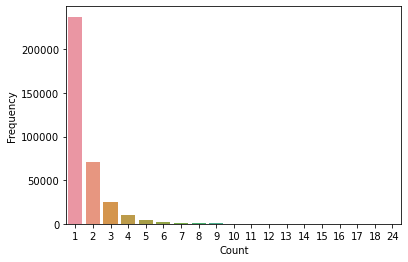

In [63]:
import seaborn as sns

sns.countplot(data=hourly_counts, x='count')
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.show()

#data['column_name'].value_counts()[value]


In [64]:
hourly_counts['NotifyLowerTierDescription'] = encoder.fit_transform(hourly_counts['NotifyLowerTierDescription'])

In [65]:
print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

{'Adjala-Tosorontio': 0, 'Aurora': 1, 'Barrie': 2, 'Blue Mountains': 3, 'Bracebridge': 4, 'Bradford - West Gwillimbury': 5, 'Brampton': 6, 'Brock': 7, 'Caledon': 8, 'Christian Island': 9, 'Clearview': 10, 'Collingwood': 11, 'District of Kenora (not designated)': 12, 'East Garafraxa': 13, 'East Gwillimbury': 14, 'Essa': 15, 'Georgian Bay': 16, 'Georgina': 17, 'Gravenhurst': 18, 'Greater City of Ottawa': 19, 'Grey Highlands': 20, 'Guelph': 21, 'Hamilton': 22, 'Huntsville': 23, 'Innisfil': 24, 'King': 25, 'London': 26, 'Markham': 27, 'Meaford': 28, 'Midland': 29, 'Mono': 30, 'Mulmur': 31, 'Muskoka Lakes': 32, 'New Tecumseth': 33, 'Newmarket': 34, 'North Bay': 35, 'Orillia': 36, 'Oro-Medonte': 37, 'Owen Sound': 38, 'Penetanguishene': 39, 'Rama First Nation 32': 40, 'Ramara': 41, 'Richmond Hill': 42, 'Scugog': 43, 'Severn': 44, 'Springwater': 45, 'Tay': 46, 'Tiny': 47, 'Toronto': 48, 'Vaughan': 49, 'Victoria': 50, 'Wasaga Beach': 51, 'Whitby': 52, 'Whitchurch - Stouffville': 53}


In [66]:
hourly_counts.columns

Index(['CallHour', 'NotifyLowerTierDescription', 'Year', 'Month', 'Day',
       'count'],
      dtype='object')

In [67]:
X = hourly_counts.drop(['count'], axis=1)
y = hourly_counts['count']

In [68]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()

X = ss.fit_transform(X)

In [69]:
X = pd.DataFrame(X, columns=hourly_counts.columns[:5])

In [70]:
X.head()

,CallHour,NotifyLowerTierDescription,Year,Month,Day
0,-2.01315,-1.547752,-1.618971,-1.626487,-1.666247
1,-2.01315,-1.547752,-1.618971,-1.626487,-1.552916
2,-2.01315,-1.547752,-1.618971,-1.626487,-1.326255
3,-2.01315,-1.547752,-1.618971,-1.626487,-0.079619
4,-2.01315,-1.547752,-1.618971,-1.626487,0.260373


In [71]:
X.shape

(352555, 5)

In [72]:
X.to_csv('X.csv', index=False)
y.to_csv('y.csv', index=False)